<a href="https://colab.research.google.com/github/ShreyaKantamsetty/bank-campaign-prediction/blob/main/notebooks/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup


In [4]:
!pip install imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

#Data Load

In [2]:
from google.colab import files
uploaded = files.upload()   # bank-additional-full.csv select karo

Saving bank-additional-full.csv to bank-additional-full.csv


In [5]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#Step 1: Explore and Clean

**Basic shape ,target balance**

In [8]:
print(df.shape)
print(df['y'].value_counts(normalize=True)*100)

(41188, 21)
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


**Shape:** 41,188 rows, 20 features + target `y`

**Target balance:** ~89% no, ~11% yes (imbalanced)

**Dtypes + unknowns**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Numerical features**:
age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

**Categorical features**:
job, marital, education, default, housing, loan, contact, month, day of week, poutcome

In [19]:
# To check in every categorical column how many times 'unknown' has occured
for col in df.select_dtypes(include='object').columns:
    if 'unknown' in df[col].unique():
        print(col, ':', (df[col] == 'unknown').sum(),
              f"({round((df[col] == 'unknown').mean()*100, 2)}%)")

job : 330 (0.8%)
marital : 80 (0.19%)
education : 1731 (4.2%)
default : 8597 (20.87%)
housing : 990 (2.4%)
loan : 990 (2.4%)


In [18]:
# Are housing and loan unknowns the same clients?
(df['housing'] == 'unknown').equals(df['loan'] == 'unknown')

True

In [20]:
pd.crosstab(df['default'], df['y'], normalize='index')

y,no,yes
default,,
no,0.87121,0.12879
unknown,0.94847,0.05153
yes,1.00000,0.00000


**Unknown value analysis:**
- default: 8,597 (20.87%) — high proportion, likely non-disclosure
- education: 1,731 (4.20%)
- housing: 990 (2.40%)
- loan: 990 (2.40%)
- job: 330 (0.80%)
- marital: 80 (0.19%)

Confirmed: housing and loan 'unknown' values occur in the exact same 990 rows — these clients declined to answer both loan-related questions together.

Decision: keep 'unknown' as its own category during encoding (not imputed), since non-disclosure may itself carry predictive signal, especially for `default` given its high rate.

Verified: default=unknown clients subscribe at 5.15%, notably lower than default=no clients at 12.88%, and far higher than default=yes clients at 0%. This confirms non-disclosure is not equivalent to "no" and carries distinct predictive signal, supporting the decision to keep 'unknown' as its own category rather than imputing it.

**Unusual Values**

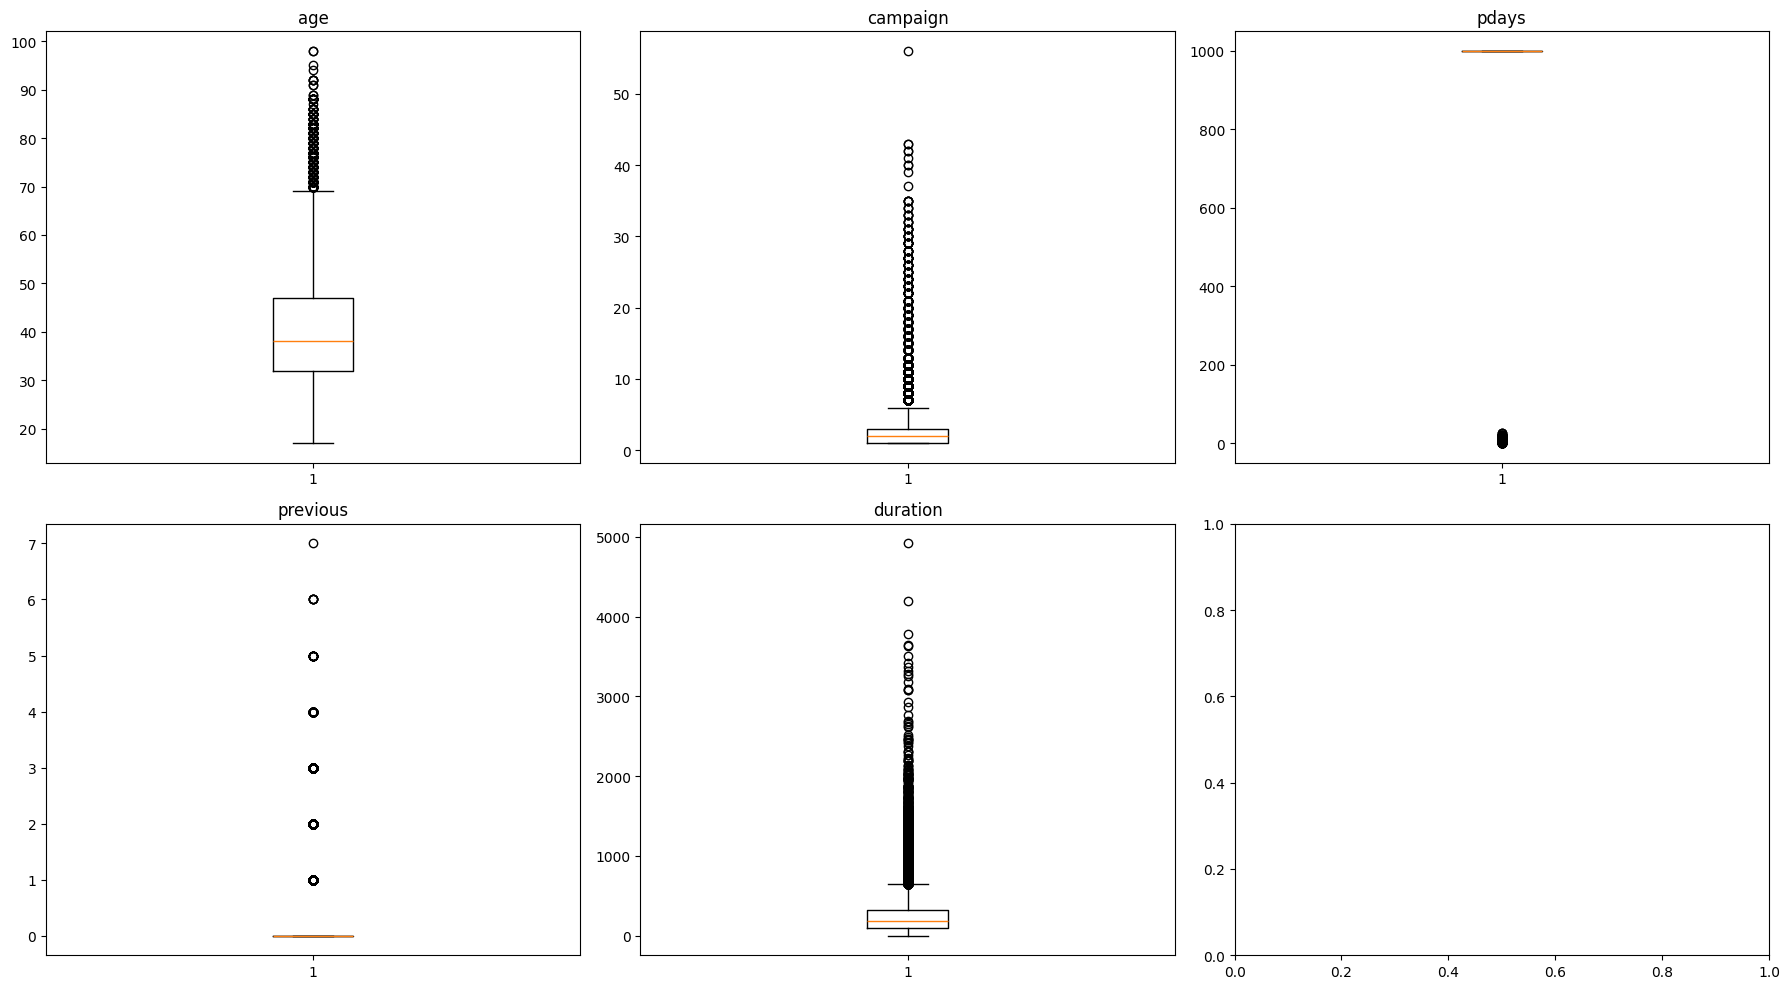

In [10]:
numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'duration']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [11]:
for col in ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']:
    print(col, ':', df[col].nunique(), 'unique values')

emp.var.rate : 10 unique values
cons.price.idx : 26 unique values
cons.conf.idx : 26 unique values
euribor3m : 316 unique values
nr.employed : 11 unique values


**Outliers:** age, campaign, duration all show genuine extreme values (not data errors) — e.g. campaign up to 56 contacts, duration up to ~4900s. No removal needed; tree-based models are robust to these. Economic indicator columns (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) have very few unique values (10–316) — they're time-period markers, not per-client features, so not boxplotted individually.

In [12]:
df[df['pdays'] != 999]['pdays'].describe()

,pdays
count,1515.000000
mean,6.014521
std,3.824906
min,0.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,27.000000


**Special code:** `pdays = 999` means client was never previously contacted. Excluding 999, actual gap ranges 0–27 days (mean ~6). Needs a separate flag column, not treated as a numeric outlier.

In [24]:
df[['age', 'campaign', 'previous', 'duration']].describe()

,age,campaign,previous,duration
count,41188.00000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,0.172963,258.285010
std,10.42125,2.770014,0.494901,259.279249
min,17.00000,1.000000,0.000000,0.000000
25%,32.00000,1.000000,0.000000,102.000000
50%,38.00000,2.000000,0.000000,180.000000
75%,47.00000,3.000000,0.000000,319.000000
max,98.00000,56.000000,7.000000,4918.000000


No negative or impossible values found in numeric columns (age: 17–98, duration: 0–4918, campaign: 1–56, previous: 0–7 — all valid ranges)

In [25]:
df.duplicated().sum()

np.int64(12)

In [27]:
df = df.drop_duplicates().reset_index(drop=True)

In [29]:
df.shape

(41176, 21)

12 exact duplicate rows found (0.03% of data) and removed

In [26]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

job ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital ['married' 'single' 'divorced' 'unknown']
education ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default ['no' 'unknown' 'yes']
housing ['no' 'yes' 'unknown']
loan ['no' 'yes' 'unknown']
contact ['telephone' 'cellular']
month ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome ['nonexistent' 'failure' 'success']
y ['no' 'yes']


Categorical columns checked for inconsistent labeling (typos, case mismatches) — none found; all categories are clean and as expected.


**Relevant Relationships**

In [14]:
# Check how poutcome(outcome of the last campaign) effects y
pd.crosstab(df['poutcome'], df['y'], normalize='index')

y,no,yes
poutcome,,
failure,0.857714,0.142286
nonexistent,0.911678,0.088322
success,0.348871,0.651129


In [15]:
# month vs y (seasonality)
pd.crosstab(df['month'], df['y'], normalize='index').sort_values('yes', ascending=False)

y,no,yes
month,,
mar,0.494505,0.505495
dec,0.510989,0.489011
sep,0.550877,0.449123
oct,0.561281,0.438719
apr,0.795213,0.204787
aug,0.893979,0.106021
jun,0.894885,0.105115
nov,0.898561,0.101439
jul,0.909534,0.090466


In [16]:
# previous contact ka asar
df.groupby('y')['previous'].mean()

,previous
y,
no,0.132374
yes,0.492672


In [7]:
pd.crosstab(df['job'], df['y'], normalize='index').sort_values('yes', ascending=False)

y,no,yes
job,,
student,0.685714,0.314286
retired,0.747674,0.252326
unemployed,0.857988,0.142012
admin.,0.870274,0.129726
management,0.887825,0.112175
unknown,0.887879,0.112121
technician,0.891740,0.108260
self-employed,0.895144,0.104856
housemaid,0.900000,0.100000


**Key relationships found:**
- `poutcome`: success → 65% subscribe vs. 9–14% for failure/nonexistent — strongest signal so far
- `month`: strong seasonality — mar/dec/sep/oct high (40–50%), may/jun/aug/jul/nov low (6–13%)
- `previous`: subscribers average 0.49 vs. non-subscribers 0.13
- `job`: Students and retired people are more likely to subscribe

<Axes: >

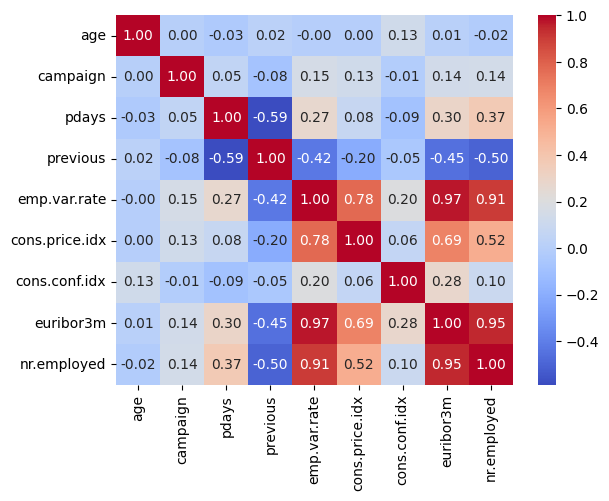

In [23]:
numeric_cols = ['age', 'campaign', 'pdays', 'previous',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

Multivariate Feature Correlation Check

**Why this was done:** To check whether any numeric features were highly correlated with each other (redundant), since this can cause instability in coefficient-based models (Logistic Regression, LDA, QDA), even though it doesn't affect tree-based models. This was a diagnostic check, not intended to drive feature removal for the tree-based candidates.

**Method:** Pearson correlation heatmap on all numeric columns.

**Findings:**
- The four economic indicators — `emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed` — are strongly correlated with each other (r = 0.78–0.97), since they all reflect overall economic conditions at the time of contact.
- `cons.conf.idx` is comparatively independent of the other economic indicators (r = 0.06–0.28).
- `previous` and `pdays` show a moderate negative correlation (r = -0.59) — more past contacts tends to mean more recent contact, which is expected.
- `age` and `campaign` show negligible correlation with other features.

**Decision:** All features were retained. Random Forest and Boosting (the final candidate models) are not sensitive to multicollinearity, so redundancy among the economic indicators does not need to be resolved for them. This correlation is noted here because it likely contributes to the instability seen in LDA/QDA (Section: Required Algorithm Studies), and would be revisited (e.g., dropping `euribor3m`/`nr.employed` in favor of `emp.var.rate`) only if a coefficient-based model were selected as final.



**Flags for feature audit (next step):**
- `duration` — excludes (post-call leakage)
- `campaign` — mild leakage concern (counts current call); consider `campaign - 1`
- `pdays`, `previous`, `poutcome` — safe, pre-call history